# 🎮 Video Game Sales — Exploratory Data Analysis

## 📌 Project Overview

The video game industry has evolved significantly over the years, driven by changes in gaming platforms, consumer preferences, genres, publishers, and regional markets.

This project analyzes historical video game sales data to uncover market trends, identify commercially successful games, and understand differences in gaming preferences across major regions.

The analysis follows a structured Exploratory Data Analysis (EDA) approach, combining data cleaning, statistical analysis, visualization, and business interpretation.

### 🛠️ Tools & Technologies

- Python
- NumPy
- Pandas
- Matplotlib
- Kaggle Notebook

### 📊 Analysis Workflow

**Data Understanding → Data Cleaning → Exploratory Data Analysis → Business Questions → Insights → Recommendations → Conclusion**

## 🎯 Business Objective

The objective of this analysis is to extract meaningful business insights from historical video game sales data.

The analysis aims to understand:

- How global video game sales have changed over time
- Which gaming platforms generate the highest sales
- Which genres perform best commercially
- Which publishers have the strongest sales performance
- What characteristics are common among top-selling games
- How gaming preferences differ across major regional markets

These insights can help stakeholders understand historical market behavior and identify patterns associated with successful video game products.

## ❓ Business Questions

This project will answer six key business questions:

### Q1. How have global video game sales changed over time?

Analyze yearly sales trends to identify periods of market growth, peak performance, and decline.

### Q2. Which gaming platforms have generated the highest global sales?

Identify the platforms with the strongest overall commercial performance.

### Q3. Which video game genres generate the highest global sales?

Determine which genres have historically attracted the highest sales.

### Q4. Which publishers have the strongest global sales performance?

Identify the leading publishers based on their total global sales.

### Q5. Which games are the best-selling titles globally, and what do they have in common?

Analyze the highest-selling games and examine their platforms, genres, and publishers.

### Q6. How do regional gaming preferences differ across major markets?

Compare sales across North America, Europe, Japan, and other regions to identify differences in market preferences.

## 🛠️ 1. Import Required Libraries

The analysis will use three core Python libraries:

- **NumPy** — numerical calculations and statistical operations
- **Pandas** — data manipulation, cleaning, and analysis
- **Matplotlib** — data visualization

No additional visualization or analysis libraries will be used.

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 📂 2. Load the Dataset

The dataset contains historical video game information, including game names, platforms, release years, genres, publishers, regional sales, and global sales.

We will first load the dataset into a Pandas DataFrame and perform an initial inspection before beginning the data cleaning process.

In [3]:
# Load the dataset

df = pd.read_csv('/kaggle/input/datasets/gregorut/videogamesales/vgsales.csv')
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 🔎 3. Initial Dataset Inspection

Before performing any cleaning or analysis, we will inspect the structure and quality of the dataset.

The initial inspection will focus on:

- Dataset dimensions
- Column names
- Data types
- Missing values
- Duplicate records
- Statistical summary

This step helps us understand the dataset and identify potential data-quality issues before analysis.

### 3.1 Dataset Dimensions

Let's determine the number of observations and variables available in the dataset.

In [4]:
# Display the number of rows and columns

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 16598
Number of Columns: 11


### 3.2 Column Names

Let's examine the available variables and understand the structure of the dataset.

In [5]:
# Display column names

df.columns.tolist()

['Rank',
 'Name',
 'Platform',
 'Year',
 'Genre',
 'Publisher',
 'NA_Sales',
 'EU_Sales',
 'JP_Sales',
 'Other_Sales',
 'Global_Sales']

### 3.3 Data Types & Structure

Understanding the data types of each column is important for identifying columns that may require conversion during the data-cleaning process.

In [6]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


### 3.4 Missing Values

Missing values can affect calculations and visualizations. We will identify the number of missing values in each column before deciding how they should be handled.

In [7]:
# Check missing values

df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

### 3.5 Duplicate Records

Duplicate records can distort analysis and sales calculations. We will check whether the dataset contains any completely duplicated rows.

In [8]:
# Check duplicate records

df.duplicated().sum()

np.int64(0)

### 3.6 Statistical Summary

Let's examine the descriptive statistics of the numerical variables to understand their distributions and overall ranges.

In [9]:
# Generate descriptive summary

df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


## 🧹 4. Data Cleaning

Data cleaning is an important step before performing exploratory analysis because missing or inconsistent values can affect calculations, comparisons, and visualizations.

Based on the initial inspection, the dataset contains:

- **271 missing values** in the `Year` column
- **58 missing values** in the `Publisher` column
- **0 duplicate records**
- Sales-related columns are already stored in appropriate numerical formats

We will handle the missing values carefully while preserving as much valid information as possible.

### 4.1 Missing Value Analysis

The number of missing values alone does not indicate their overall impact on the dataset.

We will calculate the percentage of missing values in each column to determine whether the missing data is significant.

In [10]:
# Calculate missing values and their percentage

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary[missing_summary['Missing Values'] > 0]

,Missing Values,Missing Percentage
Year,271,1.63
Publisher,58,0.35


### 4.2 Handling Missing Publisher Values

Only 58 records have missing publisher information, representing a very small portion of the dataset.

Since the remaining information for these games is still valuable for sales analysis, we will retain these records and replace the missing publisher values with **"Unknown"**.

This approach prevents unnecessary data loss while clearly identifying records with unavailable publisher information.

In [11]:
# Replace missing publisher values

df['Publisher'] = df['Publisher'].fillna('Unknown')

In [13]:
# Verify missing Publisher values

df['Publisher'].isnull().sum()

np.int64(0)

### 4.3 Handling Missing Year Values

The `Year` column contains 271 missing values.

Because the release year is a time-based variable, replacing missing values with the mean or median year could introduce inaccurate information and distort yearly sales trends.

Therefore, the missing years will be retained as `NaN`.

For analyses involving release year, only records with valid year information will be used.

This allows us to preserve the sales information from these games without introducing artificial dates.

In [14]:
# Convert Year to nullable integer type

df['Year'] = df['Year'].astype('Int64')

In [15]:
# Check updated data types

df.dtypes

Rank              int64
Name             object
Platform         object
Year              Int64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

### 4.5 Cleaning Validation

After handling the identified missing values, we will verify the dataset to ensure that:

- Publisher no longer contains missing values
- Year retains only genuinely unavailable values
- No duplicate records were introduced
- The dataset still contains all original observations

In [16]:
# Validate the cleaned dataset

print("Rows after cleaning:", df.shape[0])
print("Columns after cleaning:", df.shape[1])
print("Missing Publisher values:", df['Publisher'].isnull().sum())
print("Missing Year values:", df['Year'].isnull().sum())
print("Duplicate records:", df.duplicated().sum())

Rows after cleaning: 16598
Columns after cleaning: 11
Missing Publisher values: 0
Missing Year values: 271
Duplicate records: 0


## 📊 5. Exploratory Data Analysis

With the dataset cleaned and validated, we can now begin the exploratory analysis.

The first stage focuses on understanding the distribution of the key numerical variables, particularly regional and global video game sales.

This will provide a foundation for the deeper business-question analysis that follows.

### 5.1 Sales Distribution Overview

The dataset contains sales information for four major regions:

- North America
- Europe
- Japan
- Other Regions

These regional sales contribute to the overall **Global Sales** figure.

We will examine their central tendency and distribution before comparing regional performance.

In [17]:
# Select sales columns for analysis

sales_columns = [
    'NA_Sales',
    'EU_Sales',
    'JP_Sales',
    'Other_Sales',
    'Global_Sales'
]

df[sales_columns].describe()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,0.264667,0.146652,0.077782,0.048063,0.537441
std,0.816683,0.505351,0.309291,0.188588,1.555028
min,0.000000,0.000000,0.000000,0.000000,0.010000
25%,0.000000,0.000000,0.000000,0.000000,0.060000
50%,0.080000,0.020000,0.000000,0.010000,0.170000
75%,0.240000,0.110000,0.040000,0.040000,0.470000
max,41.490000,29.020000,10.220000,10.570000,82.740000


### 5.2 Total Sales by Region

Total sales provide a clearer view of the contribution of each geographical market to the overall video game industry.

We will calculate the cumulative sales across all games for each region.

In [18]:
# Calculate total sales by region

regional_sales = df[
    ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
].sum()

regional_sales

NA_Sales       4392.95
EU_Sales       2434.13
JP_Sales       1291.02
Other_Sales     797.75
dtype: float64

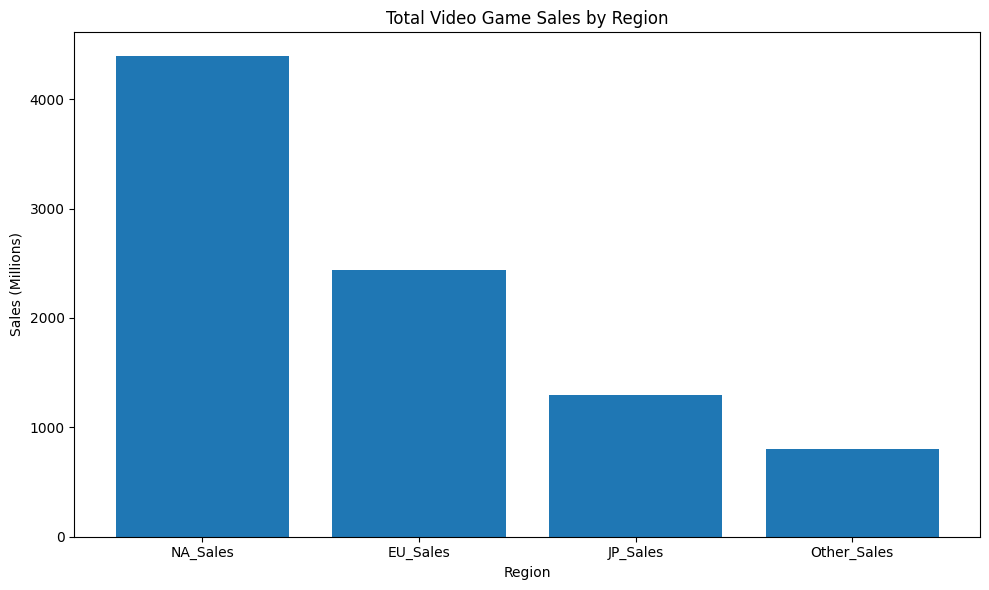

In [19]:
# Visualize total sales by region

plt.figure(figsize=(10, 6))

plt.bar(
    regional_sales.index,
    regional_sales.values
)

plt.title('Total Video Game Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales (Millions)')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.3 Games by Platform

The video game market contains numerous gaming platforms released across different generations.

Understanding the number of games associated with each platform helps us identify which platforms have had the largest presence in the dataset.

We will identify the most represented platforms based on the number of games released.

In [20]:
# Count games by platform

platform_counts = df['Platform'].value_counts()

platform_counts.head(10)

Platform
DS      2163
PS2     2161
PS3     1329
Wii     1325
X360    1265
PSP     1213
PS      1196
PC       960
XB       824
GBA      822
Name: count, dtype: int64

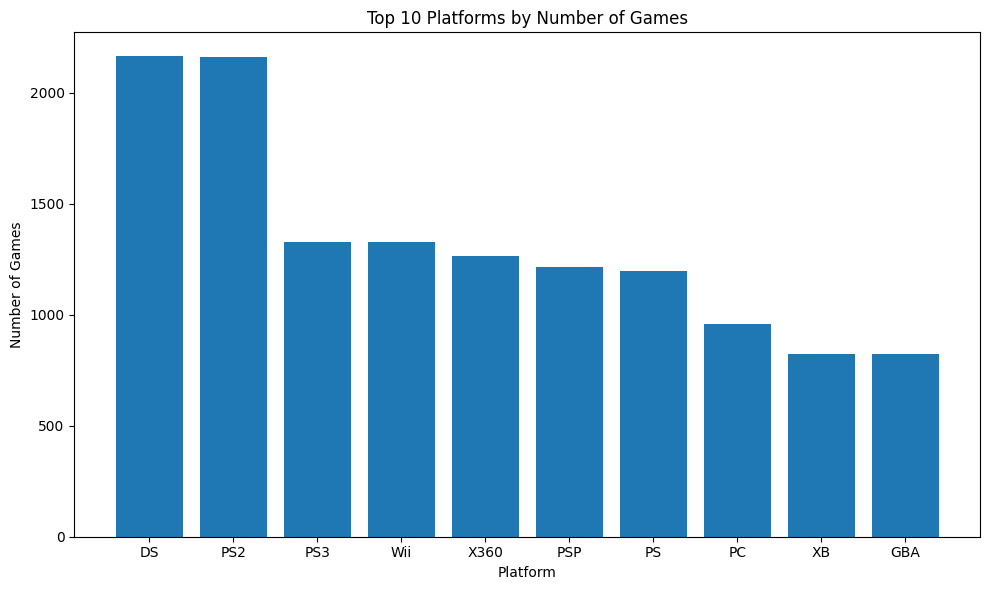

In [21]:
# Visualize the top 10 platforms by number of games

top_platforms = platform_counts.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_platforms.index,
    top_platforms.values
)

plt.title('Top 10 Platforms by Number of Games')
plt.xlabel('Platform')
plt.ylabel('Number of Games')

plt.tight_layout()
plt.show()

### 5.4 Games by Genre

Game genre is an important indicator of consumer preferences and market composition.

We will examine the number of games available in each genre to understand which categories dominate the dataset.

In [22]:
# Count games by genre

genre_counts = df['Genre'].value_counts()

genre_counts

Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64

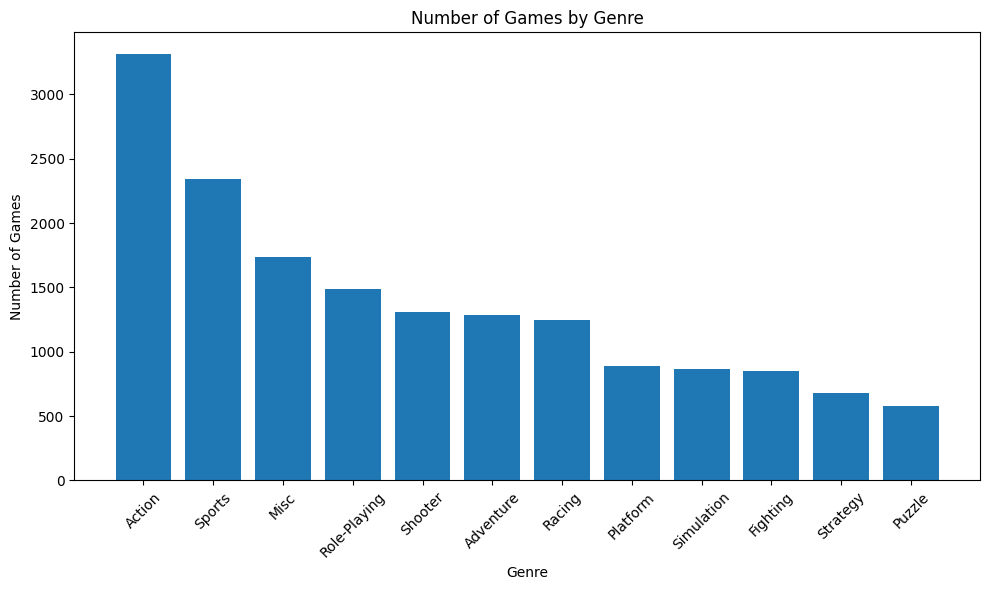

In [23]:
# Visualize games by genre

plt.figure(figsize=(10, 6))

plt.bar(
    genre_counts.index,
    genre_counts.values
)

plt.title('Number of Games by Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Games')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.5 Games by Publisher

Publishers play a major role in the development and distribution of video games.

Because the dataset contains a large number of publishers, we will focus on the top publishers based on the number of games represented in the dataset.

In [24]:
# Count games by publisher

publisher_counts = df['Publisher'].value_counts()

publisher_counts.head(10)

Publisher
Electronic Arts                 1351
Activision                       975
Namco Bandai Games               932
Ubisoft                          921
Konami Digital Entertainment     832
THQ                              715
Nintendo                         703
Sony Computer Entertainment      683
Sega                             639
Take-Two Interactive             413
Name: count, dtype: int64

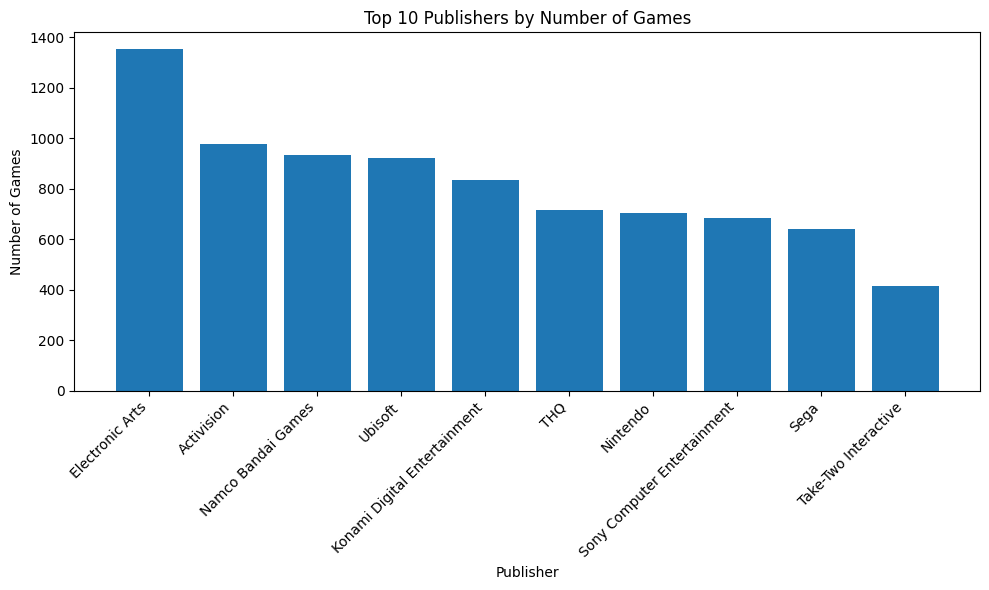

In [25]:
# Visualize the top 10 publishers by number of games

top_publishers = publisher_counts.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_publishers.index,
    top_publishers.values
)

plt.title('Top 10 Publishers by Number of Games')
plt.xlabel('Publisher')
plt.ylabel('Number of Games')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.6 Global Sales Distribution

Global sales vary substantially between video game titles.

Most games generate relatively modest sales, while a small number of highly successful titles account for exceptionally high sales.

We will visualize the distribution of global sales to understand this pattern.

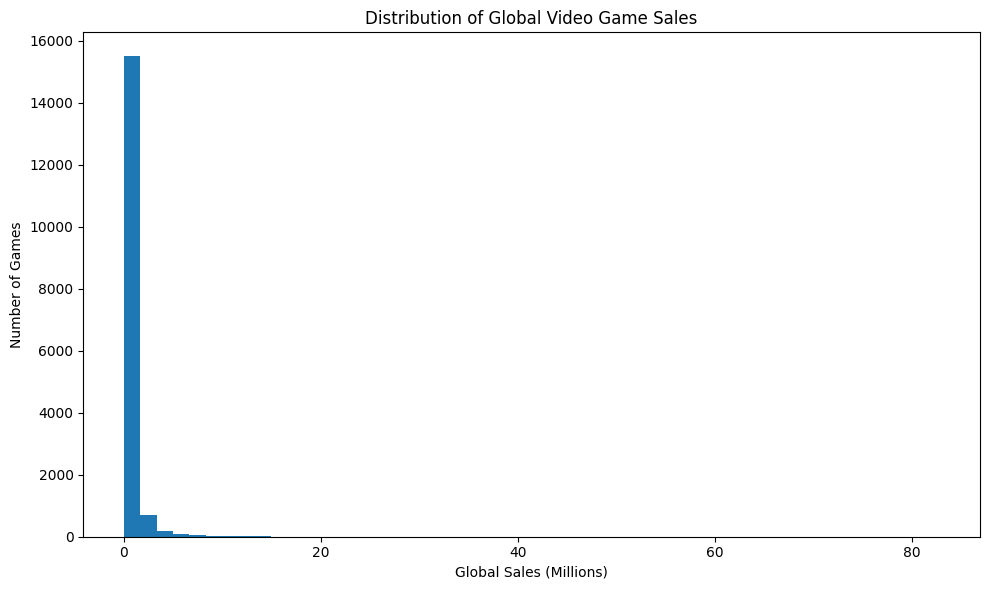

In [26]:
# Plot the distribution of global sales

plt.figure(figsize=(10, 6))

plt.hist(
    df['Global_Sales'],
    bins=50
)

plt.title('Distribution of Global Video Game Sales')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Number of Games')

plt.tight_layout()
plt.show()

## 🎯 Business Question 1

### How have global video game sales changed over time?

#### 🎯 Business Objective

To analyze the historical trend in global video game sales and identify periods of market growth, peak performance, and decline.

Understanding these trends can help stakeholders evaluate how the video game market has evolved over different periods.

### 🔎 Preparing Data for Time-Based Analysis

The `Year` column contains 271 missing values.

Since these records cannot be assigned to a specific year without introducing assumptions, they will be excluded only from this time-based analysis.

All other records remain available for the rest of the project.

In [27]:
# Create a dataset containing only records with valid release years

yearly_data = df.dropna(subset=['Year']).copy()

print("Records available for yearly analysis:", len(yearly_data))

Records available for yearly analysis: 16327


### 📊 Calculate Global Sales by Year

We will aggregate global sales by release year to understand how the industry's sales performance has changed over time.

In [28]:
# Calculate total global sales for each year

yearly_sales = (
    yearly_data
    .groupby('Year')['Global_Sales']
    .sum()
    .sort_index()
)

yearly_sales.head()

Year
1980    11.38
1981    35.77
1982    28.86
1983    16.79
1984    50.36
Name: Global_Sales, dtype: float64

### 📈 Global Video Game Sales Trend

The following line chart shows the total global sales of video games across the available release years.

A line chart is appropriate here because the objective is to observe how sales changed over time.

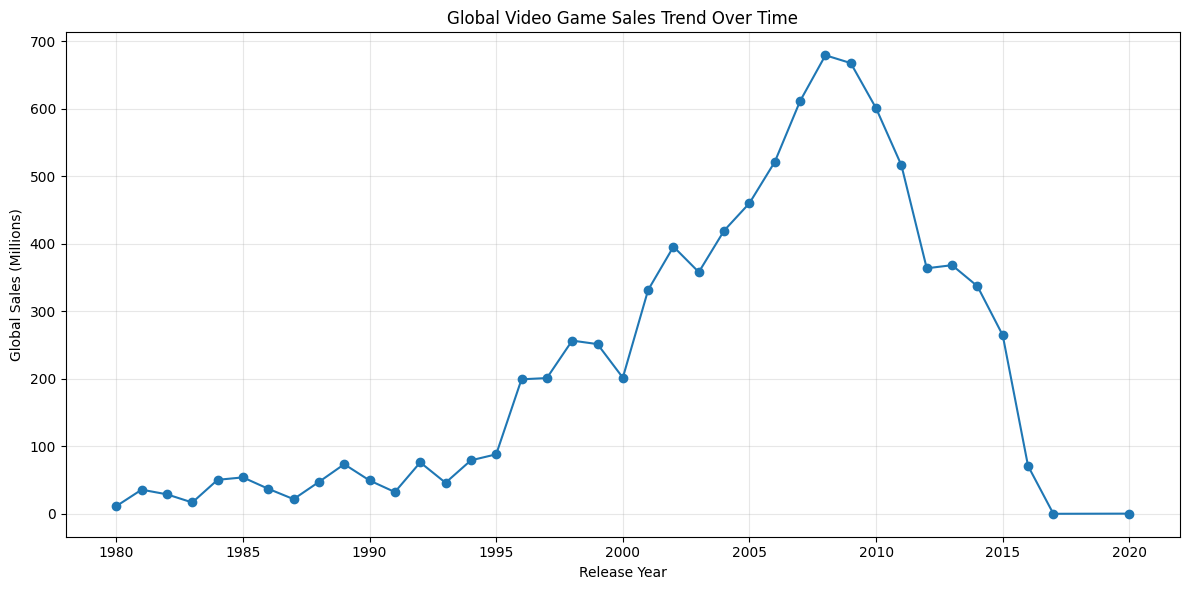

In [29]:
# Plot yearly global sales trend

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker='o'
)

plt.title('Global Video Game Sales Trend Over Time')
plt.xlabel('Release Year')
plt.ylabel('Global Sales (Millions)')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 🏆 Peak Sales Year

To identify the strongest period in the dataset, we will determine the year with the highest total global video game sales.

In [30]:
# Identify the year with the highest global sales

peak_year = yearly_sales.idxmax()
peak_sales = yearly_sales.max()

print("Peak Sales Year:", peak_year)
print("Global Sales:", round(peak_sales, 2), "million")

Peak Sales Year: 2008
Global Sales: 678.9 million


### 🏆 Top 5 Years by Global Sales

To obtain a broader understanding of peak market performance, we will identify the five years with the highest total global video game sales.

In [32]:
# Identify the top 5 years by global sales

top_5_years = (
    yearly_sales
    .sort_values(ascending=False)
    .head(5)
)

top_5_years

Year
2008    678.90
2009    667.30
2007    611.13
2010    600.45
2006    521.04
Name: Global_Sales, dtype: float64

### 💡 Business Insight

Global video game sales reached their highest point in **2008**, with total sales of **678.90 million units**.

The strongest five years were:

| Rank | Year | Global Sales (Millions) |
|---|---:|---:|
| 1 | 2008 | 678.90 |
| 2 | 2009 | 667.30 |
| 3 | 2007 | 611.13 |
| 4 | 2010 | 600.45 |
| 5 | 2006 | 521.04 |

The results show that the video game market experienced particularly strong sales performance between **2006 and 2010**, with 2008 representing the peak year in the dataset.

The decline after 2008 suggests that the market's annual sales volume began weakening after this peak period.

### 📌 Business Takeaway

The period around **2006–2010 represents a major high-performance phase** in the historical video game market. Businesses analyzing historical demand should pay particular attention to the platforms, genres, publishers, and games that contributed to this peak.

## 🎯 Business Question 2

### Which gaming platforms have generated the highest global sales?

#### 🎯 Business Objective

To identify the gaming platforms with the highest total global sales and determine which platforms have demonstrated the strongest commercial performance historically.

This analysis will help distinguish between platform presence and actual sales performance.

### 📊 Calculate Global Sales by Platform

We will aggregate global sales for each platform and rank them from highest to lowest.

In [33]:
# Calculate total global sales by platform

platform_sales = (
    df.groupby('Platform')['Global_Sales']
      .sum()
      .sort_values(ascending=False)
)

platform_sales.head(10)

Platform
PS2     1255.64
X360     979.96
PS3      957.84
Wii      926.71
DS       822.49
PS       730.66
GBA      318.50
PSP      296.28
PS4      278.10
PC       258.82
Name: Global_Sales, dtype: float64

### 📈 Top 10 Platforms by Global Sales

The following visualization compares the ten platforms with the highest cumulative global video game sales.

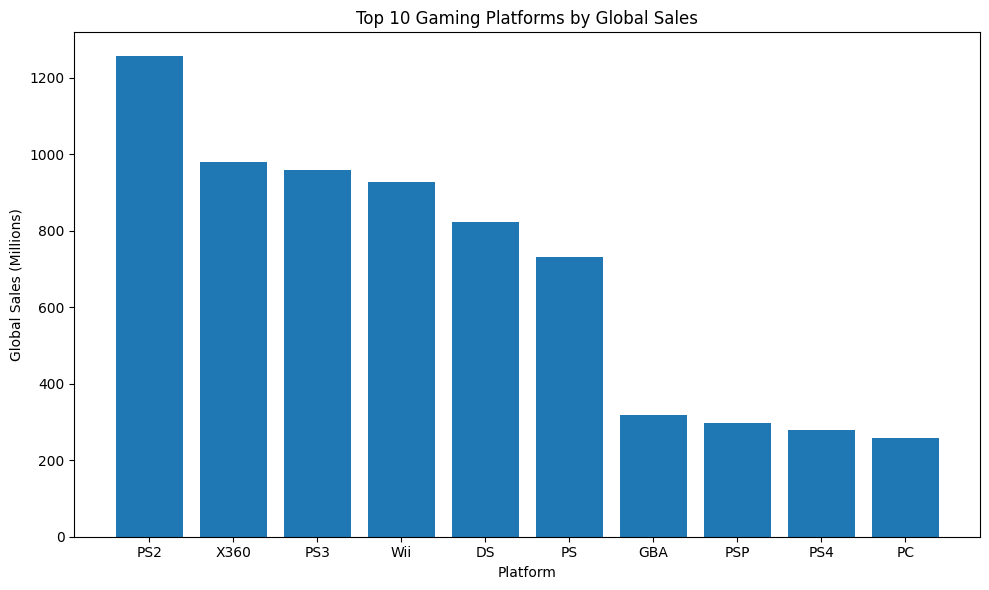

In [34]:
# Select the top 10 platforms

top_10_platform_sales = platform_sales.head(10)

# Plot top 10 platforms by global sales

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_platform_sales.index,
    top_10_platform_sales.values
)

plt.title('Top 10 Gaming Platforms by Global Sales')
plt.xlabel('Platform')
plt.ylabel('Global Sales (Millions)')

plt.tight_layout()
plt.show()

### 🏆 Highest-Selling Platform

In [35]:
# Identify the highest-selling platform

top_platform = platform_sales.idxmax()
top_platform_sales = platform_sales.max()

print("Top Platform:", top_platform)
print("Global Sales:", round(top_platform_sales, 2), "million")


Top Platform: PS2
Global Sales: 1255.64 million


### 💡 Business Insight

The **PlayStation 2 (PS2)** is the highest-selling platform in the dataset, generating **1,255.64 million units** in global sales.

The Top 10 platforms by cumulative global sales are:

| Rank | Platform | Global Sales (Millions) |
|---|---|---:|
| 1 | PS2 | 1,255.64 |
| 2 | X360 | 979.96 |
| 3 | PS3 | 957.84 |
| 4 | Wii | 926.71 |
| 5 | DS | 822.49 |
| 6 | PS | 730.66 |
| 7 | GBA | 318.50 |
| 8 | PSP | 296.28 |
| 9 | PS4 | 278.10 |
| 10 | PC | 258.82 |

PS2 generated approximately **28% more global sales than the X360**, the second-highest platform in the dataset.

A notable pattern is the strong presence of **Sony PlayStation platforms**, with PS2, PS3, PS, PSP, and PS4 all appearing among the Top 10 platforms.

### 📌 Business Takeaway

Platform selection has historically been an important factor in video game commercial performance. The dominance of PS2 suggests that its large installed user base and extensive game library played an important role in driving overall software sales.

For publishers, understanding the scale and historical performance of a platform can help inform decisions around **game development, platform targeting, and distribution strategy**.

## 🎯 Business Question 3

### Which video game genres generate the highest global sales?

#### 🎯 Business Objective

To identify the genres that generate the highest cumulative global sales and determine which types of games have demonstrated the strongest commercial demand historically.

Comparing genre sales with the number of games within each genre can also help distinguish between market presence and commercial performance.

### 📊 Calculate Global Sales by Genre

We will aggregate global sales for each genre and rank the genres from highest to lowest.

In [36]:
# Calculate total global sales by genre

genre_sales = (
    df.groupby('Genre')['Global_Sales']
      .sum()
      .sort_values(ascending=False)
)

genre_sales

Genre
Action          1751.18
Sports          1330.93
Shooter         1037.37
Role-Playing     927.37
Platform         831.37
Misc             809.96
Racing           732.04
Fighting         448.91
Simulation       392.20
Puzzle           244.95
Adventure        239.04
Strategy         175.12
Name: Global_Sales, dtype: float64

### 📈 Top Genres by Global Sales

The following visualization compares the commercial performance of different video game genres based on cumulative global sales.

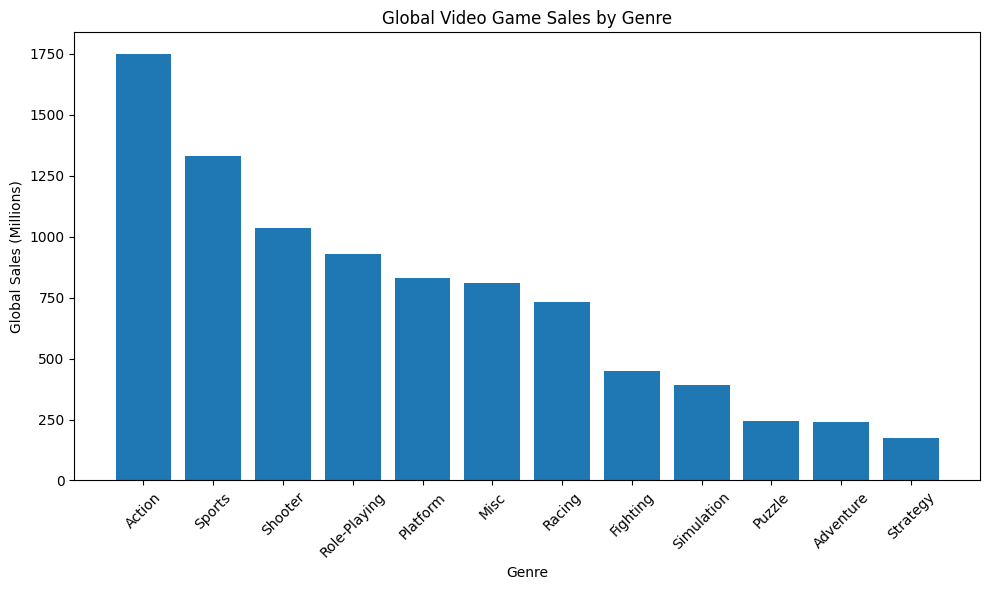

In [37]:
# Plot global sales by genre

plt.figure(figsize=(10, 6))

plt.bar(
    genre_sales.index,
    genre_sales.values
)

plt.title('Global Video Game Sales by Genre')
plt.xlabel('Genre')
plt.ylabel('Global Sales (Millions)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
# Identify the highest-selling genre

top_genre = genre_sales.idxmax()
top_genre_sales = genre_sales.max()

print("Top Genre:", top_genre)
print("Global Sales:", round(top_genre_sales, 2), "million")

Top Genre: Action
Global Sales: 1751.18 million


### 💡 Business Insight

The **Action** genre generated the highest cumulative global sales, reaching **1,751.18 million units** across the dataset.

This indicates that Action games have historically had the strongest overall commercial performance among the available genres.

However, cumulative sales alone do not tell us whether a genre is successful because it has a large number of games or because its individual titles perform strongly. Therefore, genre sales should be considered alongside the number of titles released within each genre.

### 📌 Business Takeaway

The strong performance of the **Action** genre indicates substantial historical consumer demand for Action games.

For publishers and developers, this suggests that Action has been an important commercial category. However, market entry decisions should not rely on genre popularity alone; competition, platform selection, title quality, and regional preferences should also be considered.

## 🎯 Business Question 4

### Which publishers have the strongest global sales performance?

#### 🎯 Business Objective

To identify the publishers with the highest cumulative global video game sales and determine which companies have demonstrated the strongest commercial performance historically.

This analysis will help distinguish leading publishers based on actual sales performance rather than simply the number of games they have released.

### 📊 Calculate Global Sales by Publisher

We will aggregate global sales for each publisher and rank them from highest to lowest.

In [39]:
# Calculate total global sales by publisher

publisher_sales = (
    df.groupby('Publisher')['Global_Sales']
      .sum()
      .sort_values(ascending=False)
)

publisher_sales.head(10)

Publisher
Nintendo                        1786.56
Electronic Arts                 1110.32
Activision                       727.46
Sony Computer Entertainment      607.50
Ubisoft                          474.72
Take-Two Interactive             399.54
THQ                              340.77
Konami Digital Entertainment     283.64
Sega                             272.99
Namco Bandai Games               254.09
Name: Global_Sales, dtype: float64

### 📈 Top 10 Publishers by Global Sales

The following chart compares the publishers with the highest cumulative global video game sales.

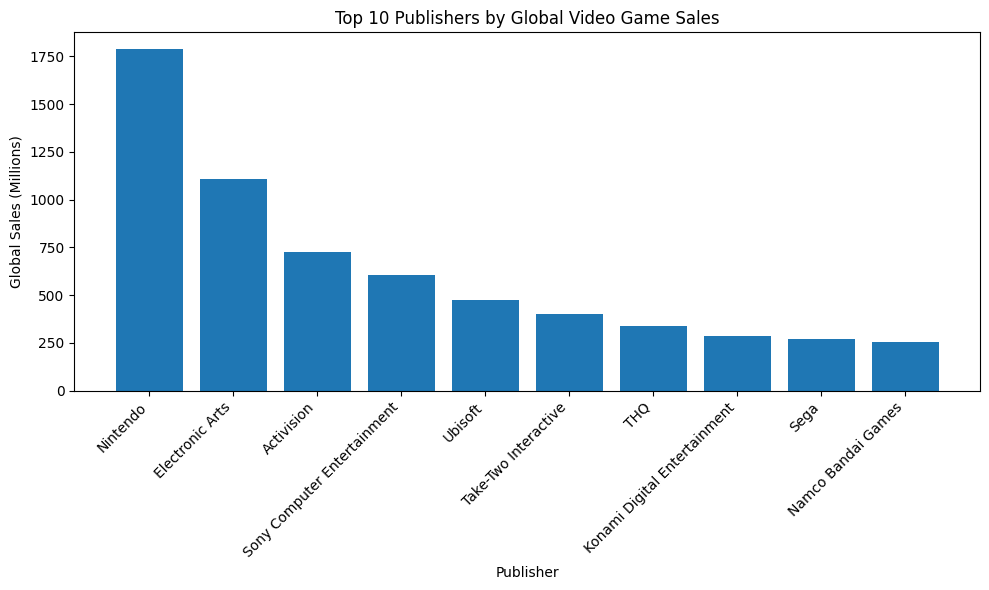

In [40]:
# Select the top 10 publishers

top_10_publishers = publisher_sales.head(10)

# Plot top 10 publishers by global sales

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_publishers.index,
    top_10_publishers.values
)

plt.title('Top 10 Publishers by Global Video Game Sales')
plt.xlabel('Publisher')
plt.ylabel('Global Sales (Millions)')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [41]:
# Identify the publisher with the highest global sales

top_publisher = publisher_sales.idxmax()
top_publisher_sales = publisher_sales.max()

print("Top Publisher:", top_publisher)
print("Global Sales:", round(top_publisher_sales, 2), "million")

Top Publisher: Nintendo
Global Sales: 1786.56 million


### 💡 Business Insight

**Nintendo** is the highest-selling publisher in the dataset, generating **1,786.56 million units** in cumulative global sales.

The Top 10 publishers by global sales are:

| Rank | Publisher | Global Sales (Millions) |
|---|---|---:|
| 1 | Nintendo | 1,786.56 |
| 2 | Electronic Arts | 1,110.32 |
| 3 | Activision | 727.46 |
| 4 | Sony Computer Entertainment | 607.50 |
| 5 | Ubisoft | 474.72 |
| 6 | Take-Two Interactive | 399.54 |
| 7 | THQ | 340.77 |
| 8 | Konami Digital Entertainment | 283.64 |
| 9 | Sega | 272.99 |
| 10 | Namco Bandai Games | 254.09 |

Nintendo generated approximately **60.9% more global sales than Electronic Arts**, the second-highest publisher in the dataset.

The results also show a substantial gap between the top publishers and the remaining companies, indicating that sales performance is concentrated among a relatively small group of major publishers.

### 📌 Business Takeaway

Nintendo's leading position highlights the importance of strong intellectual properties, established franchises, platform ecosystems, and a large global customer base in driving long-term video game sales.

For publishers, the results suggest that sustained commercial success depends not only on releasing a high number of games, but also on building successful franchises and maintaining strong relationships with gaming platforms and consumers.

## 🎯 Business Question 5

### Which games are the best-selling titles globally, and what do they have in common?

#### 🎯 Business Objective

To identify the highest-selling individual video games and examine their common characteristics across platforms, genres, and publishers.

Understanding the characteristics of blockbuster titles can help reveal patterns associated with exceptional commercial performance.

### 🏆 Top 10 Best-Selling Games

We will rank individual games based on their Global Sales and identify the ten highest-selling titles in the dataset.

In [42]:
# Identify the top 10 best-selling games

top_10_games = (
    df[['Name', 'Platform', 'Genre', 'Publisher', 'Global_Sales']]
    .sort_values('Global_Sales', ascending=False)
    .head(10)
)

top_10_games

,Name,Platform,Genre,Publisher,Global_Sales
0,Wii Sports,Wii,Sports,Nintendo,82.74
1,Super Mario Bros.,NES,Platform,Nintendo,40.24
2,Mario Kart Wii,Wii,Racing,Nintendo,35.82
3,Wii Sports Resort,Wii,Sports,Nintendo,33.00
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,Nintendo,31.37
5,Tetris,GB,Puzzle,Nintendo,30.26
6,New Super Mario Bros.,DS,Platform,Nintendo,30.01
7,Wii Play,Wii,Misc,Nintendo,29.02
8,New Super Mario Bros. Wii,Wii,Platform,Nintendo,28.62
9,Duck Hunt,NES,Shooter,Nintendo,28.31


### 📈 Top 10 Games by Global Sales

The following visualization highlights the individual titles that achieved the highest global sales.

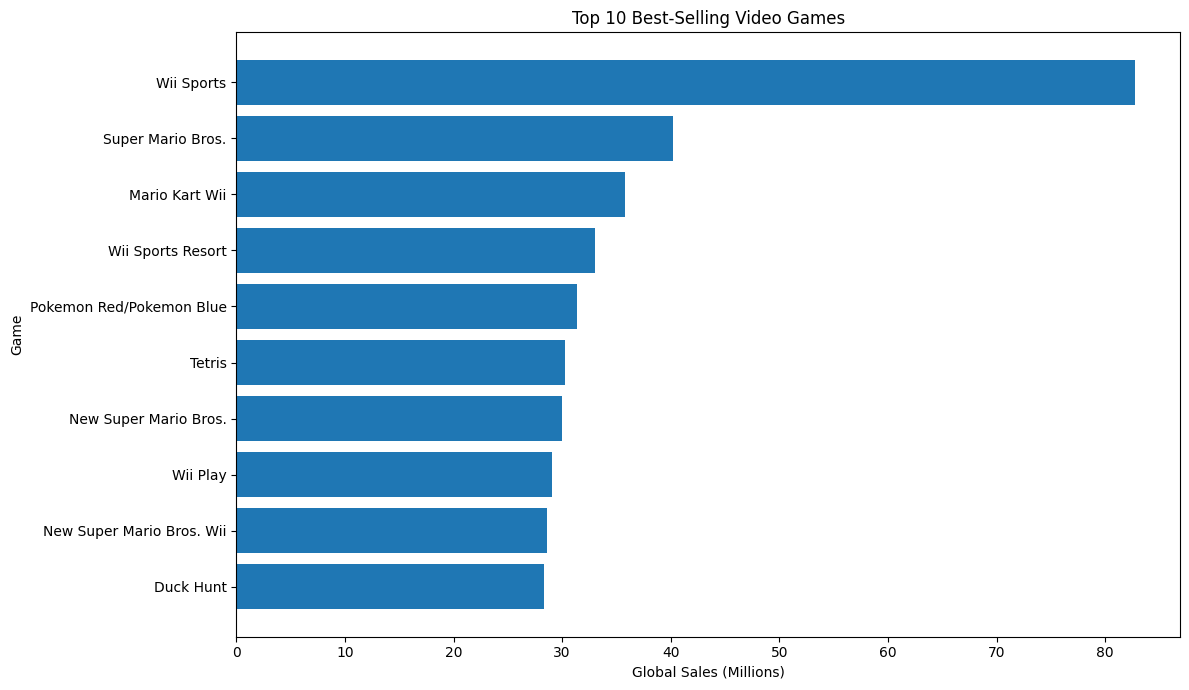

In [43]:
# Plot the top 10 best-selling games

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_games['Name'][::-1],
    top_10_games['Global_Sales'][::-1]
)

plt.title('Top 10 Best-Selling Video Games')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Game')

plt.tight_layout()
plt.show()

In [49]:
# Analyze the platforms represented among the top 10 games

top_10_games['Platform'].value_counts()

Platform
Wii    5
NES    2
GB     2
DS     1
Name: count, dtype: int64

In [45]:
# Analyze the genres represented among the top 10 games

top_10_games['Genre'].value_counts()

Genre
Platform        3
Sports          2
Racing          1
Role-Playing    1
Puzzle          1
Misc            1
Shooter         1
Name: count, dtype: int64

In [46]:
# Analyze the publishers represented among the top 10 games

top_10_games['Publisher'].value_counts()

Publisher
Nintendo    10
Name: count, dtype: int64

In [47]:
# Calculate combined global sales of the top 10 games

top_10_total_sales = top_10_games['Global_Sales'].sum()

print("Combined Global Sales of Top 10 Games:",
      round(top_10_total_sales, 2), "million")

Combined Global Sales of Top 10 Games: 369.39 million


## 🎯 Business Question 6

### How do regional gaming preferences differ across major markets?

#### 🎯 Business Objective

To compare video game sales across North America, Europe, Japan, and other regions and identify differences in consumer preferences.

Understanding regional behavior can help publishers and developers evaluate where different genres and games perform most strongly.

### 📊 Regional Market Comparison

We will first calculate total sales for each major geographical market to understand the relative size of each region in the dataset.

In [50]:
# Calculate total sales by region

regional_sales = df[
    ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
].sum().sort_values(ascending=False)

regional_sales

NA_Sales       4392.95
EU_Sales       2434.13
JP_Sales       1291.02
Other_Sales     797.75
dtype: float64

### 📈 Total Sales by Region

The following visualization compares cumulative video game sales across the four regional markets.

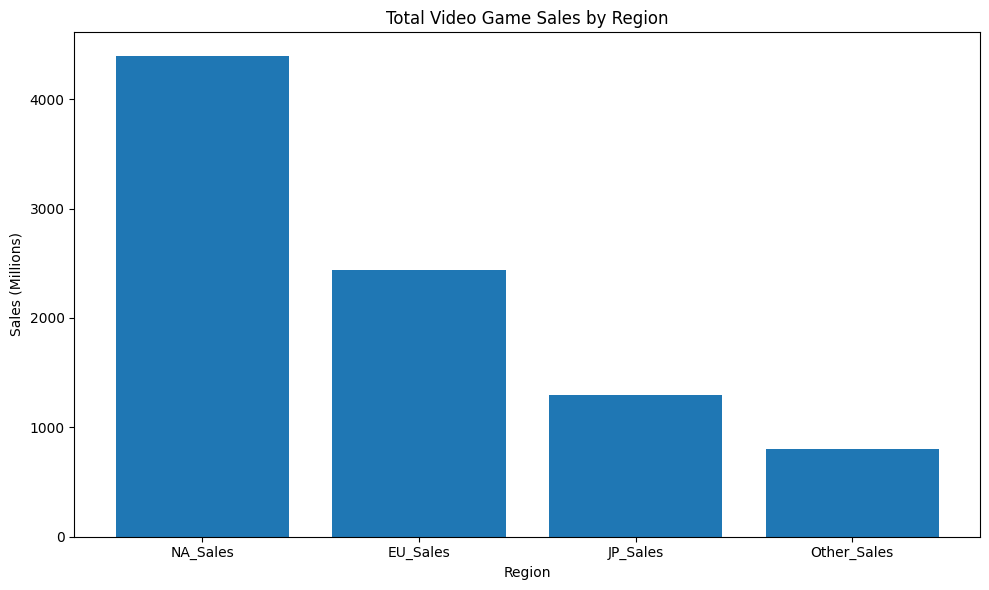

In [51]:
# Plot total sales by region

plt.figure(figsize=(10, 6))

plt.bar(
    regional_sales.index,
    regional_sales.values
)

plt.title('Total Video Game Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales (Millions)')

plt.tight_layout()
plt.show()

### 🎮 Genre Preferences Across Regions

Total regional sales show the relative size of each market, but they do not explain differences in consumer preferences.

To investigate regional behavior, we will calculate the total sales generated by each genre within each region.

In [52]:
# Calculate genre sales across major regions

regional_genre_sales = df.groupby('Genre')[
    ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
].sum()

regional_genre_sales

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,877.83,525.00,159.95,187.38
Adventure,105.80,64.13,52.07,16.81
Fighting,223.59,101.32,87.35,36.68
Misc,410.24,215.98,107.76,75.32
Platform,447.05,201.63,130.77,51.59
Puzzle,123.78,50.78,57.31,12.55
Racing,359.42,238.39,56.69,77.27
Role-Playing,327.28,188.06,352.31,59.61
Shooter,582.60,313.27,38.28,102.69


### 🏆 Top-Selling Genre in Each Region

We will identify the genre with the highest cumulative sales in each geographical market.

In [53]:
# Identify the highest-selling genre in each region

top_genre_by_region = regional_genre_sales.idxmax()

top_sales_by_region = regional_genre_sales.max()

regional_summary = pd.DataFrame({
    'Top Genre': top_genre_by_region,
    'Sales (Millions)': top_sales_by_region.round(2)
})

regional_summary

,Top Genre,Sales (Millions)
NA_Sales,Action,877.83
EU_Sales,Action,525.00
JP_Sales,Role-Playing,352.31
Other_Sales,Action,187.38


### 📊 Comparing Genre Performance Across Regions

To compare regional preferences more clearly, we will visualize genre sales across the four markets.

Each line represents a region, allowing us to identify where genre performance differs most significantly.

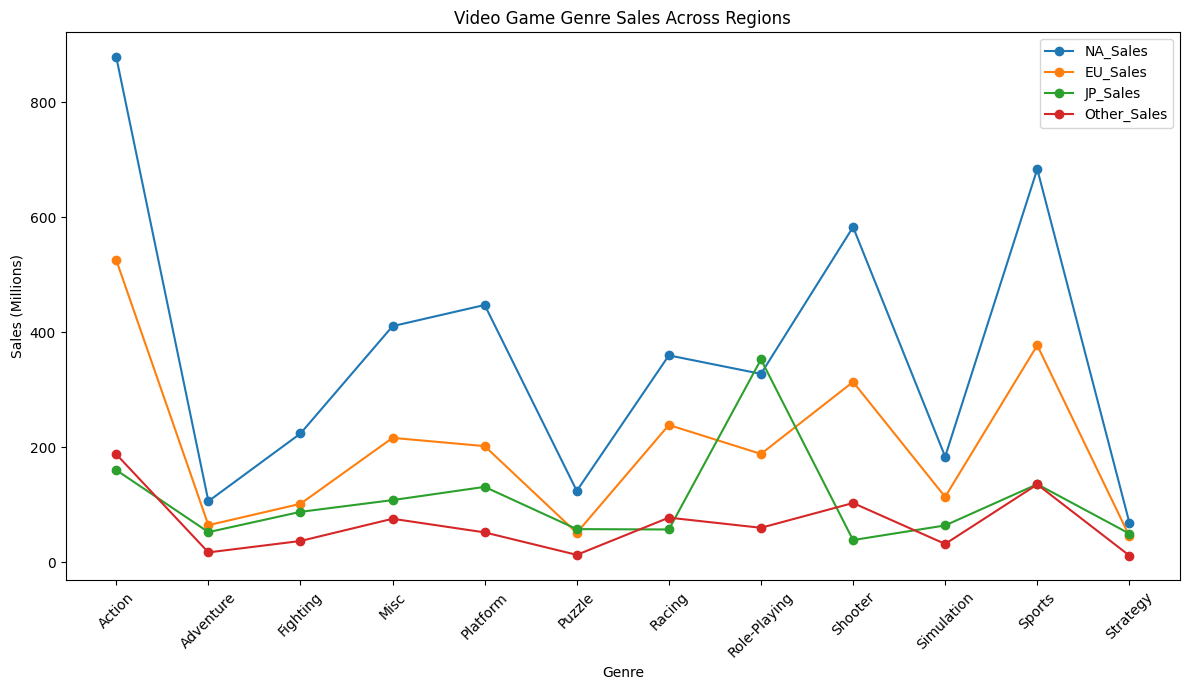

In [54]:
# Plot genre sales across regions

plt.figure(figsize=(12, 7))

for region in regional_genre_sales.columns:
    plt.plot(
        regional_genre_sales.index,
        regional_genre_sales[region],
        marker='o',
        label=region
    )

plt.title('Video Game Genre Sales Across Regions')
plt.xlabel('Genre')
plt.ylabel('Sales (Millions)')

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

### 📌 Regional Sales Contribution

We will calculate each region's percentage contribution to the combined regional sales recorded in the dataset.

In [55]:
# Calculate regional contribution percentages

regional_share = (
    regional_sales / regional_sales.sum() * 100
).round(2)

regional_share

NA_Sales       49.27
EU_Sales       27.30
JP_Sales       14.48
Other_Sales     8.95
dtype: float64

### 💡 Business Insight

The regional analysis reveals significant differences in both market size and genre preferences.

### 🌍 Regional Sales Performance

| Rank | Region | Sales (Millions) | Share of Regional Sales |
|---|---|---:|---:|
| 1 | North America | 4,392.95 | 49.27% |
| 2 | Europe | 2,434.13 | 27.30% |
| 3 | Japan | 1,291.02 | 14.48% |
| 4 | Other Regions | 797.75 | 8.95% |

**North America** is the largest market, accounting for **49.27%** of the combined regional sales analyzed.

Europe follows with **27.30%**, while Japan contributes **14.48%** and other regions account for **8.95%**.

### 🎮 Regional Genre Preferences

The highest-selling genre differs by region:

| Region | Highest-Selling Genre | Sales (Millions) |
|---|---|---:|
| North America | Action | 877.83 |
| Europe | Action | 525.00 |
| Japan | Role-Playing | 352.31 |
| Other Regions | Action | 187.38 |

**Action** is the leading genre in North America, Europe, and Other Regions.

However, **Japan differs significantly**, where **Role-Playing** is the highest-selling genre with **352.31 million units**.

### 📌 Business Takeaway

The results demonstrate that video game demand is not completely uniform across geographical markets.

While Action games have broad international appeal, Japan shows a stronger preference for Role-Playing games. This suggests that publishers can benefit from **regionalized game development, marketing, and distribution strategies** rather than applying a single global approach.

North America's dominant **49.27% share** also indicates that this market has historically represented the largest sales opportunity within the dataset.

## 💡 7. Key Business Insights

The analysis of **16,598 video game records** produced several important business insights:

### 1. 📈 Market Peak

Global video game sales reached their highest annual level in **2008**, with **678.90 million units** sold. The period from **2006 to 2010** represented a particularly strong phase of market performance.

### 2. 🎮 Platform Leadership

The **PS2** was the highest-selling platform, generating **1,255.64 million units** in global sales. Sony's PlayStation platforms also appeared multiple times among the Top 10 platforms.

### 3. 🕹️ Genre Demand

**Action** was the highest-selling genre, generating **1,751.18 million units** globally. This indicates strong historical consumer demand for Action games.

### 4. 🏢 Publisher Dominance

**Nintendo** was the leading publisher with **1,786.56 million units** in global sales.

More significantly, Nintendo published **all 10 of the highest-selling individual games** in the dataset, demonstrating exceptional performance at both publisher and individual-title levels.

### 5. 🏆 Blockbuster Concentration

The Top 10 best-selling games generated a combined **369.39 million units**.

The **Wii appeared in 5 of these titles**, while Platform games represented the largest genre group with 3 titles.

### 6. 🌍 Regional Differences

**North America** was the largest regional market, accounting for **49.27%** of combined regional sales.

Action was the leading genre in North America, Europe, and Other Regions, while **Role-Playing was the top genre in Japan**, highlighting an important regional difference in consumer preferences.

## 📈 8. Business Recommendations

Based on the analysis, the following recommendations can be considered by video game publishers and developers:

### 1. 🎯 Prioritize High-Demand Genres

Action games generated the highest cumulative global sales. Publishers should continue evaluating opportunities in high-demand genres while differentiating their products to avoid excessive competition.

### 2. 🎮 Align Games With Platform Opportunities

Historical platform performance shows that platform selection can have a major influence on software sales. Publishers should evaluate platform adoption, audience size, and historical performance when deciding where to launch new titles.

### 3. 🏆 Invest in Strong Intellectual Properties

Nintendo's dominance among the Top 10 best-selling games demonstrates the potential value of recognizable franchises and strong intellectual properties.

Developing long-term franchises can create stronger customer loyalty and repeated sales opportunities.

### 4. 🌍 Adopt Regional Strategies

The differences between North American, European, and Japanese genre preferences suggest that publishers should consider localized marketing and product strategies.

For example, Role-Playing games may receive greater strategic attention in the Japanese market, while Action games show broader international appeal.

### 5. 📊 Use Historical Trends for Strategic Planning

The strong sales period between 2006 and 2010 demonstrates the value of analyzing historical market cycles.

Publishers can combine historical sales trends with current market data when forecasting demand and planning future releases.

## 🏁 9. Conclusion

This exploratory analysis examined **16,598 video game records** to understand historical sales patterns across time, platforms, genres, publishers, individual titles, and geographical markets.

The analysis identified **2008 as the peak sales year**, while the **PS2** emerged as the highest-selling platform and **Action** as the highest-selling genre.

At the publisher level, **Nintendo** demonstrated exceptional historical performance, generating **1,786.56 million units** in global sales and publishing all ten of the highest-selling individual games in the dataset.

The regional analysis also revealed important differences in consumer preferences. **North America represented the largest market**, while Japan showed a distinct preference for **Role-Playing games** compared with the other major regions.

Overall, the analysis demonstrates that video game success is influenced by multiple factors, including **platform reach, genre demand, publisher strength, franchise appeal, timing, and regional consumer preferences**.

These findings provide a historical perspective on the video game market and demonstrate how exploratory data analysis can transform raw sales data into actionable business insights.

## 📚 10. References & Resources

The following resources were used as references for this project:

### 📊 Dataset

- **Video Game Sales Dataset** — Kaggle  
  Source: Historical video game sales data containing information on game titles, platforms, genres, publishers, regional sales, and global sales.

### 🐍 Python Documentation

- **NumPy Documentation** — Used as a reference for numerical operations and data manipulation.
- **Pandas Documentation** — Used as a reference for data loading, cleaning, grouping, aggregation, and analysis.
- **Matplotlib Documentation** — Used as a reference for creating and formatting data visualizations.

### 🔗 Resources

- [Kaggle](https://www.kaggle.com/)
- [NumPy Documentation](https://numpy.org/doc/)
- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [Matplotlib Documentation](https://matplotlib.org/stable/)

> **Note:** The analysis, calculations, visualizations, and business insights presented in this notebook were independently developed as part of this Exploratory Data Analysis project.